In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [38]:
sns.set_theme(style="whitegrid")

In [39]:
np.random.seed(42)
num_records = 400

customer_data = pd.DataFrame({
    'age_group': np.random.choice(['18-24', '25-44', '45-64', '65+'], num_records),
    'frequency': np.random.randint(1, 20, num_records),
    'monetary_value': np.random.uniform(50, 2000, num_records)
})

In [40]:
customer_data

,age_group,frequency,monetary_value
0,45-64,11,870.044768
1,65+,17,1580.103115
2,18-24,8,1296.754646
3,45-64,4,1619.837102
4,45-64,6,1811.144564
...,...,...,...
395,65+,12,1167.924037
396,65+,5,1684.308578
397,25-44,17,838.543928
398,65+,16,1553.277185


In [41]:
customer_data['customer_segment'] = pd.cut(customer_data['monetary_value'],
                                          bins=[0, 500, 1500, np.inf],
                                          labels=['Low', 'Mid', 'High'],
                                          right=False)

In [42]:
customer_data

,age_group,frequency,monetary_value,customer_segment
0,45-64,11,870.044768,Mid
1,65+,17,1580.103115,High
2,18-24,8,1296.754646,Mid
3,45-64,4,1619.837102,High
4,45-64,6,1811.144564,High
...,...,...,...,...
395,65+,12,1167.924037,Mid
396,65+,5,1684.308578,High
397,25-44,17,838.543928,Mid
398,65+,16,1553.277185,High


In [43]:
start_date = pd.to_datetime('2025-01-01')
dates = pd.date_range(start=start_date, periods=120, freq='D')
revenue = np.cumsum(np.random.uniform(100, 500, 120)) + np.linspace(0, 10000, 120) # Cumulative increasing trend
sales_data = pd.DataFrame({
    'Date': dates,
    'Revenue': revenue
})

In [44]:
sales_data

,Date,Revenue
0,2025-01-01,241.548551
1,2025-01-02,809.033035
2,2025-01-03,1066.815017
3,2025-01-04,1286.983414
4,2025-01-05,1779.411398
...,...,...
115,2025-04-26,44426.071242
116,2025-04-27,44974.240496
117,2025-04-28,45176.314381
118,2025-04-29,45404.135034


In [45]:
product_categories = ['Electronics', 'Clothing', 'Home', 'Toys']
product_data = pd.DataFrame({
    'Category': product_categories,
    'Sales': np.random.randint(5000, 25000, len(product_categories))
})

In [46]:
product_data

,Category,Sales
0,Electronics,14155
1,Clothing,15426
2,Home,15233
3,Toys,6828


In [47]:
platforms = ['Twitter', 'Instagram', 'Facebook']
content_types = ['Video', 'Image', 'Text']

social_media_data = pd.DataFrame({
    'Platform': np.random.choice(platforms, 30),
    'Content_Type': np.random.choice(content_types, 30),
    'Engagement_Rate': np.random.uniform(0.01, 0.15, 30)
})

In [48]:
social_media_data

,Platform,Content_Type,Engagement_Rate
0,Twitter,Image,0.074040
1,Twitter,Video,0.064764
2,Facebook,Video,0.048214
3,Instagram,Image,0.076735
4,Facebook,Text,0.016213
5,Facebook,Text,0.129307
6,Instagram,Video,0.014959
7,Facebook,Video,0.056067
8,Instagram,Text,0.140423
9,Twitter,Image,0.112930


/tmp/ipykernel_1940/2302181342.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age_group', data=customer_data, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_1940/2302181342.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Stage', y='Count', data=conversion_stages, ax=axes[0, 2], palette='magma')
/tmp/ipykernel_1940/2302181342.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=product_data, ax=axes[1, 1], palette='cividis')


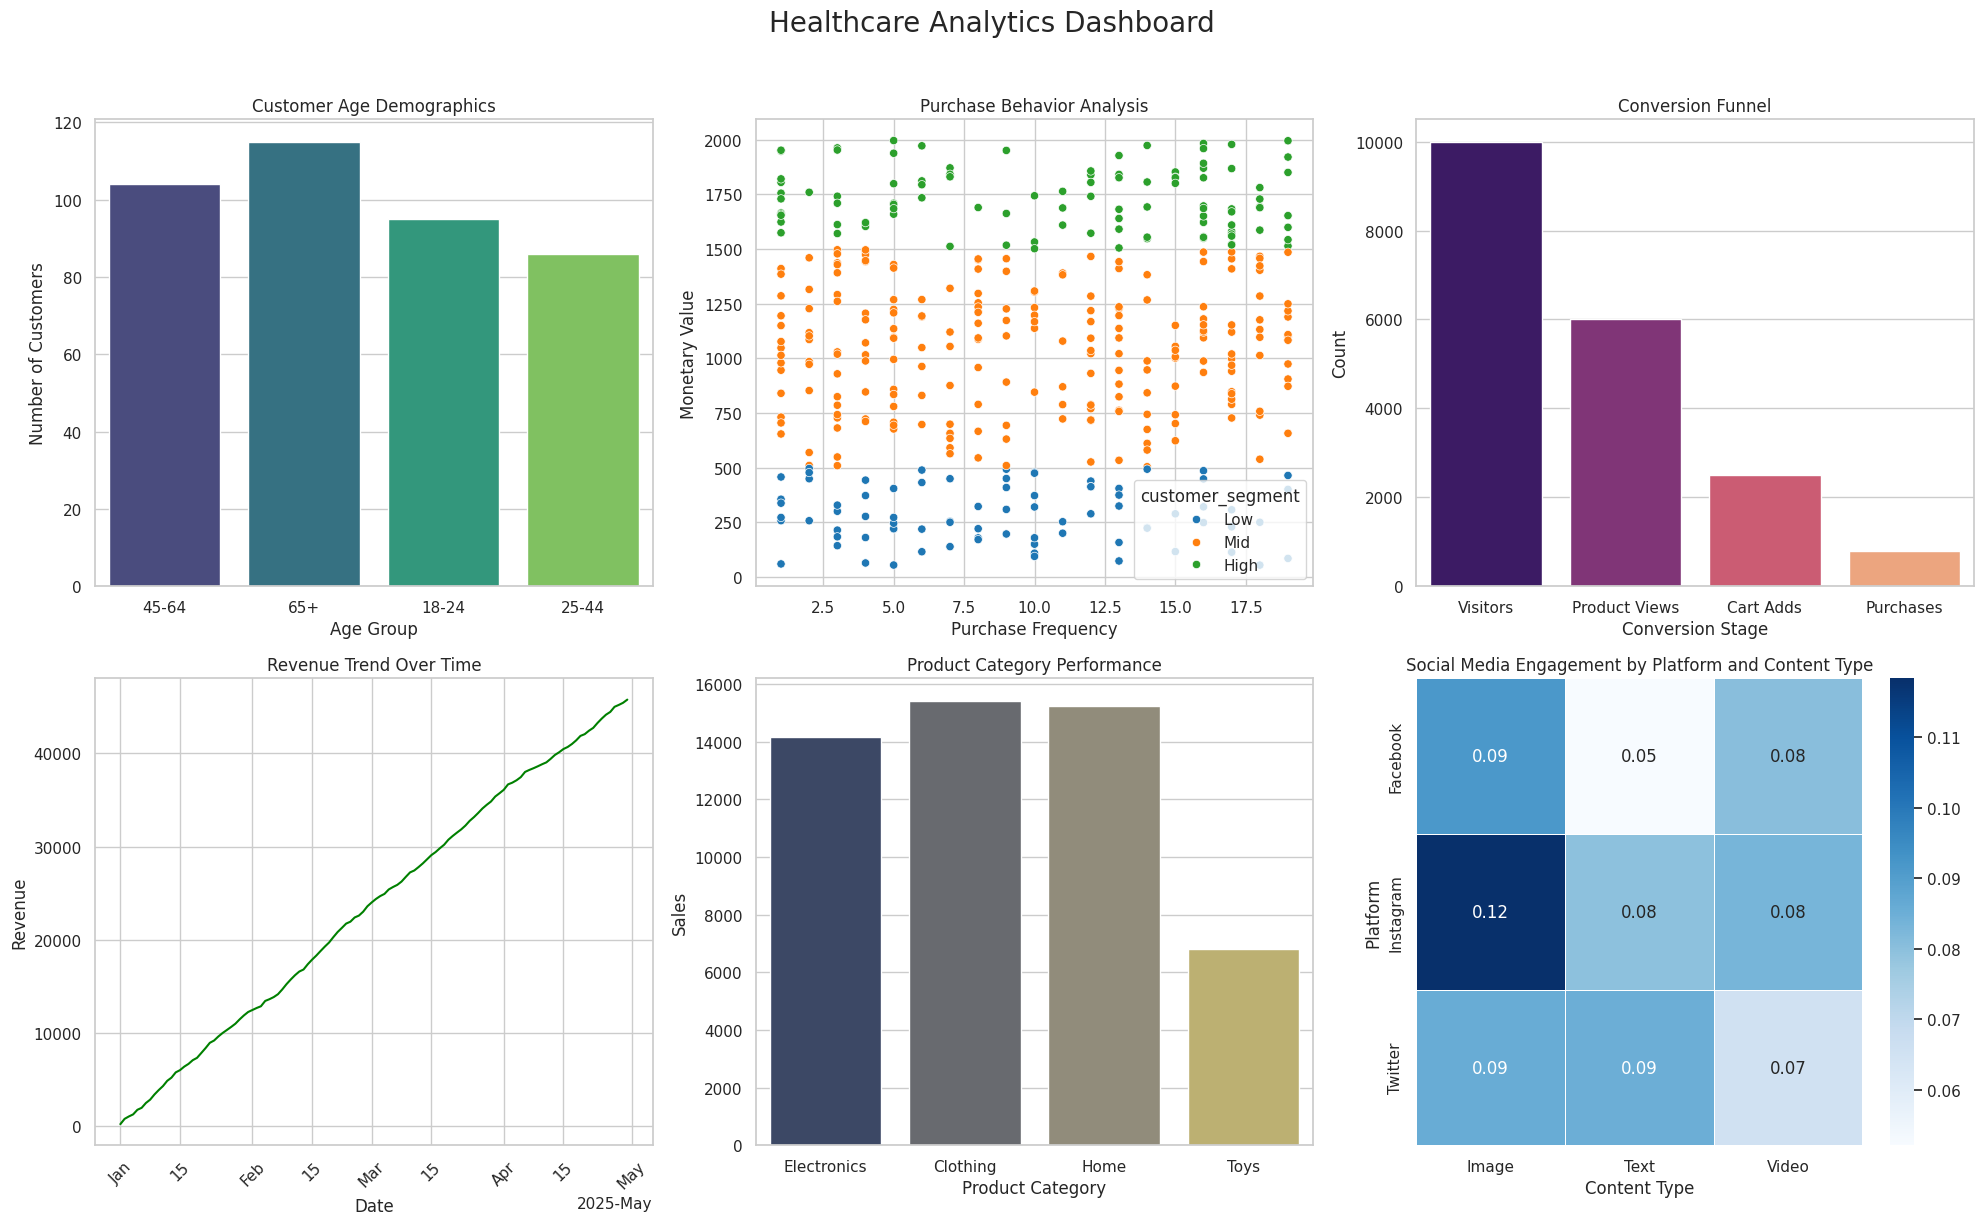

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Healthcare Analytics Dashboard', fontsize=20, y=1.02)

# 1. Customer Age Demographics
sns.countplot(x='age_group', data=customer_data, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Customer Age Demographics')
axes[0, 0].set_xlabel('Age Group')
axes[0, 0].set_ylabel('Number of Customers')

# 2. Purchase Behavior Analysis
sns.scatterplot(x='frequency', y='monetary_value', hue='customer_segment', data=customer_data, ax=axes[0, 1], palette='tab10')
axes[0, 1].set_title('Purchase Behavior Analysis')
axes[0, 1].set_xlabel('Purchase Frequency')
axes[0, 1].set_ylabel('Monetary Value')

# 3. Conversion Funnel
conversion_stages = pd.DataFrame({
    'Stage': ['Visitors', 'Product Views', 'Cart Adds', 'Purchases'],
    'Count': [10000, 6000, 2500, 800]
})
sns.barplot(x='Stage', y='Count', data=conversion_stages, ax=axes[0, 2], palette='magma')
axes[0, 2].set_title('Conversion Funnel')
axes[0, 2].set_xlabel('Conversion Stage')
axes[0, 2].set_ylabel('Count')

# 4. Revenue Trend
sns.lineplot(x='Date', y='Revenue', data=sales_data, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Revenue Trend Over Time')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Revenue')
# Format dates
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
axes[1, 0].xaxis.set_major_locator(locator)
axes[1, 0].xaxis.set_major_formatter(formatter)
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Category Performance
sns.barplot(x='Category', y='Sales', data=product_data, ax=axes[1, 1], palette='cividis')
axes[1, 1].set_title('Product Category Performance')
axes[1, 1].set_xlabel('Product Category')
axes[1, 1].set_ylabel('Sales')

# 6. Social Media Engagement
social_media_pivot = social_media_data.pivot_table(index='Platform', columns='Content_Type', values='Engagement_Rate', aggfunc='mean')
sns.heatmap(social_media_pivot, annot=True, cmap='Blues', fmt=".2f", linewidths=.5, ax=axes[1, 2])
axes[1, 2].set_title('Social Media Engagement by Platform and Content Type')
axes[1, 2].set_xlabel('Content Type')
axes[1, 2].set_ylabel('Platform')

# Final Touches
plt.tight_layout()
plt.show()